# Notebook 02 — Item Similarity

Compares two item similarity methods:
- **Method A — Embedding-based:** cosine similarity on DeepFM item latent vectors
- **Method B — Content-based:** TF-IDF on genres + tags per movie

Requires `models/item_embeddings.npy` and `models/deepfm_config.json` from Notebook 04.

In [6]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import json
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
DATA_DIR   = Path('../data/raw')
MODELS_DIR = Path('../models')

## 1. Load Data + Model Artifacts

In [7]:
movies = pd.read_csv(DATA_DIR / 'movies.csv')
tags   = pd.read_csv(DATA_DIR / 'tags.csv')

with open(MODELS_DIR / 'deepfm_config.json') as f:
    config = json.load(f)
item_mapping = {int(k): v for k, v in config['item_mapping'].items()}
reverse_item_mapping = {v: k for k, v in item_mapping.items()}

item_embeddings = np.load(MODELS_DIR / 'item_embeddings.npy')
print(f'item_embeddings shape: {item_embeddings.shape}')  # (9724, 16)
print(f'movies in config: {len(item_mapping):,}')
print(f'movies in catalog: {len(movies):,}')

item_embeddings shape: (9724, 16)
movies in config: 9,724
movies in catalog: 9,742


## 2. Method A — Embedding-based Similarity

In [8]:
def embedding_similar(raw_movie_id: int, top_n: int = 10) -> pd.DataFrame:
    idx = item_mapping[raw_movie_id]
    target = item_embeddings[idx].reshape(1, -1)
    sims = cosine_similarity(target, item_embeddings)[0]
    ranked = sorted(
        ((i, s) for i, s in enumerate(sims) if i != idx),
        key=lambda x: x[1], reverse=True
    )[:top_n]
    result_ids = [reverse_item_mapping[i] for i, _ in ranked]
    scores     = [s for _, s in ranked]
    titles     = movies.set_index('movieId').loc[result_ids, 'title'].values
    genres     = movies.set_index('movieId').loc[result_ids, 'genres'].values
    return pd.DataFrame({'movieId': result_ids, 'title': titles, 'genres': genres, 'similarity': scores})

# sample query
QUERY_ID = 1  # Toy Story
query_title = movies.loc[movies.movieId == QUERY_ID, 'title'].iloc[0]
print(f'Query: {query_title}\n')
display(embedding_similar(QUERY_ID))

Query: Toy Story (1995)



,movieId,title,genres,similarity
0,6217,"Safety of Objects, The (2001)",Drama,0.888008
1,95654,Geri's Game (1997),Animation|Children,0.844605
2,8338,Black Narcissus (1947),Drama,0.834044
3,2824,On the Ropes (1999),Documentary|Drama,0.831285
4,3073,"Sandpiper, The (1965)",Drama|Romance,0.829198
5,5938,Deathtrap (1982),Comedy|Crime|Mystery|Thriller,0.828253
6,88272,"Woman, The (2011)",Horror,0.827956
7,92348,Puss in Boots (Nagagutsu o haita neko) (1969),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.827532
8,95311,Presto (2008),Animation|Children|Comedy|Fantasy,0.826726
9,4920,"Now, Voyager (1942)",Drama|Romance,0.821251


## 3. Method B — Content-based Similarity (TF-IDF on genres + tags)

In [9]:
# build per-movie text document: genres + all tags
tag_docs = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x.str.lower())).reset_index()
tag_docs.columns = ['movieId', 'tag_doc']

movies_content = movies.merge(tag_docs, on='movieId', how='left')
movies_content['doc'] = (
    movies_content['genres'].str.replace('|', ' ', regex=False).str.replace('(no genres listed)', '', regex=False)
    + ' ' + movies_content['tag_doc'].fillna('')
).str.strip()

# only keep movies that are in item_mapping (were in training set)
movies_content = movies_content[movies_content.movieId.isin(item_mapping.keys())].reset_index(drop=True)
movie_ids_content = movies_content['movieId'].tolist()

tfidf = TfidfVectorizer(max_features=500, ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(movies_content['doc'])
print(f'TF-IDF matrix: {tfidf_matrix.shape}')

def content_similar(raw_movie_id: int, top_n: int = 10) -> pd.DataFrame:
    idx = movie_ids_content.index(raw_movie_id)
    sims = cosine_similarity(tfidf_matrix[idx], tfidf_matrix)[0]
    ranked = sorted(
        ((i, s) for i, s in enumerate(sims) if i != idx),
        key=lambda x: x[1], reverse=True
    )[:top_n]
    result_ids = [movie_ids_content[i] for i, _ in ranked]
    scores     = [s for _, s in ranked]
    titles     = movies.set_index('movieId').loc[result_ids, 'title'].values
    genres     = movies.set_index('movieId').loc[result_ids, 'genres'].values
    return pd.DataFrame({'movieId': result_ids, 'title': titles, 'genres': genres, 'similarity': scores})

print(f'\nQuery: {query_title}\n')
display(content_similar(QUERY_ID))

TF-IDF matrix: (9724, 500)

Query: Toy Story (1995)



,movieId,title,genres,similarity
0,2355,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.841653
1,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.718225
2,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.522027
3,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.522027
4,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.522027
5,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.522027
6,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,0.522027
7,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,0.522027
8,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,0.522027
9,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,0.522027


## 4. Side-by-side Comparison — 3 Query Movies

In [10]:
QUERY_IDS = {
    1    : 'Toy Story (1995)',
    296  : 'Pulp Fiction (1994)',
    318  : 'Shawshank Redemption (1994)',
}

for qid, qtitle in QUERY_IDS.items():
    print(f'\n{"="*60}')
    print(f'Query: {qtitle}')
    print(f'{"="*60}')

    emb = embedding_similar(qid, top_n=5)[['title', 'genres', 'similarity']]
    con = content_similar(qid, top_n=5)[['title', 'genres', 'similarity']]

    comparison = pd.DataFrame({
        'Embedding — Title' : emb['title'].values,
        'Emb Genres'        : emb['genres'].values,
        'Emb Sim'           : emb['similarity'].round(4).values,
        'Content — Title'   : con['title'].values,
        'Con Genres'        : con['genres'].values,
        'Con Sim'           : con['similarity'].round(4).values,
    })
    display(comparison)


Query: Toy Story (1995)


,Embedding — Title,Emb Genres,Emb Sim,Content — Title,Con Genres,Con Sim
0,"Safety of Objects, The (2001)",Drama,0.8880,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.8417
1,Geri's Game (1997),Animation|Children,0.8446,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.7182
2,Black Narcissus (1947),Drama,0.8340,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.5220
3,On the Ropes (1999),Documentary|Drama,0.8313,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.5220
4,"Sandpiper, The (1965)",Drama|Romance,0.8292,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.5220



Query: Pulp Fiction (1994)


,Embedding — Title,Emb Genres,Emb Sim,Content — Title,Con Genres,Con Sim
0,"Night at the Opera, A (1935)",Comedy|Musical|Romance,0.9068,"Big Lebowski, The (1998)",Comedy|Crime,0.5044
1,Senna (2010),Documentary,0.8943,Reservoir Dogs (1992),Crime|Mystery|Thriller,0.3910
2,Kill Bill: Vol. 2 (2004),Action|Drama|Thriller,0.8939,Fight Club (1999),Action|Crime|Drama|Thriller,0.3492
3,"Testament of Dr. Mabuse, The (Das Testament de...",Crime|Horror|Mystery|Thriller,0.8888,The Hateful Eight (2015),Western,0.3469
4,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,0.8851,Django Unchained (2012),Action|Drama|Western,0.3240



Query: Shawshank Redemption (1994)


,Embedding — Title,Emb Genres,Emb Sim,Content — Title,Con Genres,Con Sim
0,Gladiator (1992),Action|Drama,0.9070,"Green Mile, The (1999)",Crime|Drama,1.0000
1,The Intern (2015),Comedy,0.9057,Christine (1983),Horror,0.8992
2,In China They Eat Dogs (I Kina spiser de hunde...,Action|Comedy,0.8995,Cat's Eye (1985),Horror,0.8992
3,"Devil's Rejects, The (2005)",Action|Crime|Horror,0.8846,Stand by Me (1986),Adventure|Drama,0.8593
4,Philomena (2013),Comedy|Drama,0.8838,"Dead Zone, The (1983)",Thriller,0.7665


## 5. Similarity Score Distribution — both methods

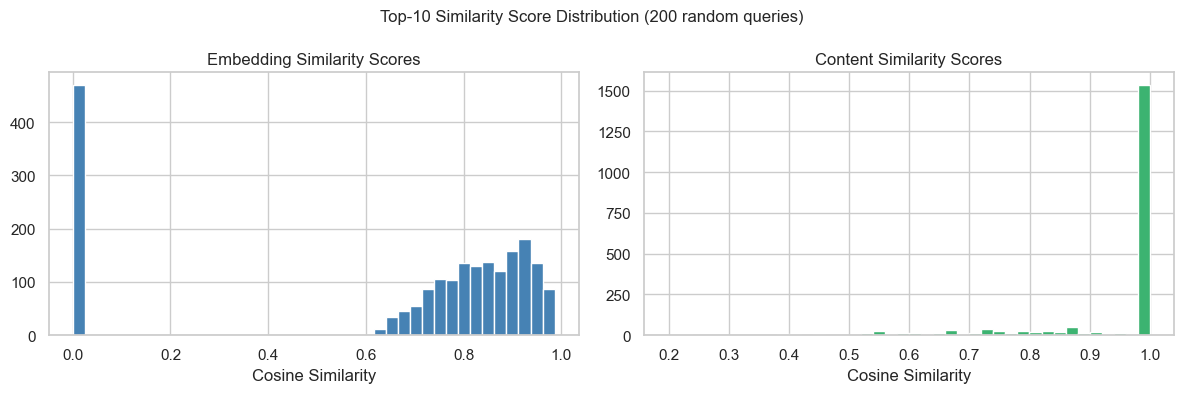

Embedding — mean: 0.6427, std: 0.3643
Content   — mean: 0.9357, std: 0.1406


In [11]:
# sample 200 random movies and compute top-10 similarity scores for each
np.random.seed(42)
sample_ids = np.random.choice(list(item_mapping.keys()), size=200, replace=False)

emb_scores, con_scores = [], []
for mid in sample_ids:
    if mid in movie_ids_content:
        emb_scores += embedding_similar(mid, top_n=10)['similarity'].tolist()
        con_scores += content_similar(mid, top_n=10)['similarity'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(emb_scores, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Embedding Similarity Scores'); axes[0].set_xlabel('Cosine Similarity')
axes[1].hist(con_scores, bins=40, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Content Similarity Scores'); axes[1].set_xlabel('Cosine Similarity')
plt.suptitle('Top-10 Similarity Score Distribution (200 random queries)', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Embedding — mean: {np.mean(emb_scores):.4f}, std: {np.std(emb_scores):.4f}')
print(f'Content   — mean: {np.mean(con_scores):.4f}, std: {np.std(con_scores):.4f}')

## 6. Discussion

**Embedding-based similarity** reflects collaborative patterns — items appear similar if users who rated one also rated the other similarly, regardless of genre. Can surface cross-genre recommendations (e.g. a drama that action fans also liked).

**Content-based similarity** reflects metadata overlap — items appear similar if they share genres and tags. More interpretable (genres are visible to users) but limited to surface-level features; two movies can share genres without appealing to the same audience.

**Which is used in production:** the backend `config.yaml` `similarity.method` key controls this — `"embedding"` by default since it leverages the trained DeepFM vectors, `"content"` available as a fallback for cold-start items not in the training set.